In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
    --------------------------------------- 1.8/101.7 MB 7.7 MB/s eta 0:00:13
   - -------------------------------------- 4.5/101.7 MB 10.3 MB/s eta 0:00:10
   -- ------------------------------------- 5.8/101.7 MB 9.3 MB/s eta 0:00:11
   --- ------------------------------------ 7.9/101.7 MB 9.4 MB/s eta 0:00:11
   --- ------------------------------------ 9.7/101.7 MB 9.2 MB/s eta 0:00:11
   ---- ----------------------------------- 11.3/101.7 MB 9.2 MB/s eta 0:00:10
   ---- ----------------------------------- 12.6/101.7 MB 8.8 MB/s eta 0:00:11
   ----- ---------------------------------- 13.9/101.7 MB 8.4 MB/s eta 0:00:11
   ----- ---------------------------------- 15.2/101.7 MB 8.1 MB/s eta 0:00:11
   ------ --------------------------------- 16.8/101.7 MB 7.9 MB/s eta 0:00:11
   ------- -------------------------------- 18.4/101.7 MB 8.0 MB/s eta 0

In [3]:
import shutil
source = r"C:\Users\AquilA#42\Downloads\creditcard.csv"
destination = "creditcard.csv"
shutil.copy(source, destination)
print("File copied to current directory.")

File copied to current directory.


In [5]:
import os
import pandas as pd

# Set the full path to your Downloads folder
downloads_path = r"C:\Users\AquilA#42\Downloads\creditcard.csv"

if os.path.exists(downloads_path):
    print(f"Loading dataset from {downloads_path}")
    df = pd.read_csv(downloads_path)
else:
    print(f"File not found at {downloads_path}. Generating synthetic data instead.")
    # ... your synthetic data generation code ...

Loading dataset from C:\Users\AquilA#42\Downloads\creditcard.csv


In [8]:
# -*- coding: utf-8 -*-
"""
Credit Card Fraud Detection
--------------------------------
This script builds a classification model to detect fraudulent transactions.
It addresses class imbalance, uses proper metrics, and compares baseline (Logistic Regression)
with an improved model (XGBoost). Threshold tuning demonstrates precision‑recall trade‑offs.

Dataset: Credit Card Fraud Detection from Kaggle
(https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

The script first looks for 'creditcard.csv' in the current folder, then in your Downloads folder.
If not found, it generates a synthetic dataset for demonstration.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, average_precision_score, precision_recall_curve,
                             accuracy_score)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# ------------------------------
# 1. Load or Generate Data
# ------------------------------
print("="*60)
print("CREDIT CARD FRAUD DETECTION")
print("="*60)

# Possible locations for the dataset
possible_paths = [
    'creditcard.csv',                                   # current directory
    r'C:\Users\AquilA#42\Downloads\creditcard.csv',     # your Downloads folder
]

df = None
for path in possible_paths:
    if os.path.exists(path):
        print(f"\nLoading dataset from {path}...")
        df = pd.read_csv(path)
        break

if df is None:
    print("\nReal dataset not found. Generating synthetic dataset for demonstration.")
    print("NOTE: Results will not reflect real‑world performance. Download the dataset from Kaggle to use real data.")
    from sklearn.datasets import make_classification
    # Generate 100k samples, 30 features, ~0.2% fraud
    X_syn, y_syn = make_classification(
        n_samples=100000,
        n_features=30,
        n_informative=15,
        n_redundant=5,
        weights=[0.998, 0.002],
        flip_y=0,
        random_state=42
    )
    # Create DataFrame similar to original (V1..V28, Amount, Time)
    columns = [f'V{i}' for i in range(1,29)] + ['Time', 'Amount']
    df_syn = pd.DataFrame(X_syn, columns=columns)
    df_syn['Class'] = y_syn
    # Make Time and Amount positive (like real data)
    df_syn['Time'] = np.abs(df_syn['Time']).astype(int)
    df_syn['Amount'] = np.abs(df_syn['Amount']) * 100
    df = df_syn
    print("Synthetic dataset created.")

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:\n{df.head()}")

# ... rest of the script (preprocessing, modeling, etc.) continues exactly as before ...

CREDIT CARD FRAUD DETECTION

Loading dataset from creditcard.csv...

Dataset shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.25

CREDIT CARD FRAUD DETECTION

Loading real dataset from creditcard.csv...

Dataset shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 

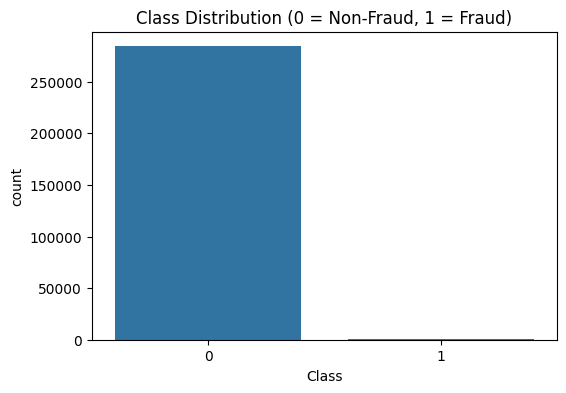


--- Why accuracy is misleading ---
If we predicted all transactions as non‑fraud, accuracy would be:
    99.83% (since frauds are only 0.17%)
But we would catch zero frauds! Hence we need precision, recall, F1, and PR‑AUC.

Features after scaling: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled', 'Time_scaled']
Feature matrix shape: (284807, 30)

Training set size: 227845
Test set size:     56962
Fraud proportion in train: 0.1729%
Fraud proportion in test:  0.1720%

BASELINE MODEL: LOGISTIC REGRESSION

--- Evaluation (threshold = 0.5) ---
Accuracy:  0.9755
Precision: 0.0609
Recall:    0.9184
F1-score:  0.1141
PR-AUC:    0.7189

Confusion Matrix:
[[55475  1389]
 [    8    90]]

IMPROVED MODEL: XGBOOST
Negative/positive ratio in training: 577.29

--- Evaluation (threshold = 0.5) ---
Accuracy:  0.9995
Precision: 0.8723
Recall:    0.836

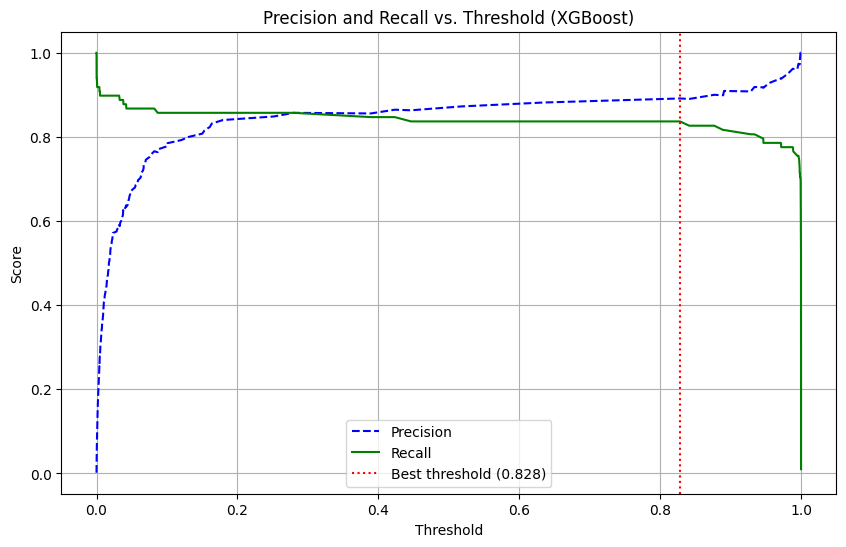


--- Evaluation with tuned threshold ---
Precision: 0.8913
Recall:    0.8367
F1-score:  0.8632
Accuracy:  0.9995

Comparison of default (0.5) vs tuned threshold:
Default F1: 0.8542  |  Tuned F1: 0.8632

KEY RESULTS

- Dataset highly imbalanced: 0.17% fraudulent transactions.
- Accuracy alone is misleading (dummy classifier would achieve 99.83%).
- Baseline Logistic Regression (class_weight='balanced'):
    Precision: 0.0609, Recall: 0.9184, F1: 0.1141, PR-AUC: 0.7189
- Improved XGBoost (scale_pos_weight=577.3):
    Precision: 0.8723, Recall: 0.8367, F1: 0.8542, PR-AUC: 0.8810
- After threshold tuning (optimising F1):
    Best threshold = 0.8282, F1 = 0.8632, Precision = 0.8913, Recall = 0.8367
- The PR‑AUC clearly reflects model performance in imbalanced setting.


Plots saved: 'class_imbalance.png', 'threshold_tuning.png'


In [10]:
# -*- coding: utf-8 -*-
"""
Credit Card Fraud Detection
--------------------------------
This script builds a classification model to detect fraudulent transactions.
It addresses class imbalance, uses proper metrics, and compares baseline (Logistic Regression)
with an improved model (XGBoost). Threshold tuning demonstrates precision‑recall trade‑offs.

Dataset: Credit Card Fraud Detection from Kaggle
(https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

The script first looks for 'creditcard.csv' in the current directory, then in your Downloads folder.
If not found, it generates a synthetic dataset for demonstration.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, average_precision_score, precision_recall_curve,
                             accuracy_score)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# ------------------------------
# 1. Load or Generate Data
# ------------------------------
print("="*60)
print("CREDIT CARD FRAUD DETECTION")
print("="*60)

# List of possible file locations
possible_paths = [
    'creditcard.csv',                                      # current directory
    r'C:\Users\AquilA#42\Downloads\creditcard.csv'        # your Downloads folder
]

df = None
for path in possible_paths:
    if os.path.exists(path):
        print(f"\nLoading real dataset from {path}...")
        df = pd.read_csv(path)
        break

if df is None:
    print("\nReal dataset not found. Generating synthetic dataset for demonstration.")
    print("NOTE: Results will not reflect real‑world performance. Download the dataset from Kaggle to use real data.")
    from sklearn.datasets import make_classification
    # Generate 100k samples, 30 features, ~0.2% fraud
    X_syn, y_syn = make_classification(
        n_samples=100000,
        n_features=30,
        n_informative=15,
        n_redundant=5,
        weights=[0.998, 0.002],
        flip_y=0,
        random_state=42
    )
    # Create DataFrame similar to original (V1..V28, Amount, Time)
    columns = [f'V{i}' for i in range(1,29)] + ['Time', 'Amount']
    df_syn = pd.DataFrame(X_syn, columns=columns)
    df_syn['Class'] = y_syn
    # Make Time and Amount positive (like real data)
    df_syn['Time'] = np.abs(df_syn['Time']).astype(int)
    df_syn['Amount'] = np.abs(df_syn['Amount']) * 100
    df = df_syn
    print("Synthetic dataset created.")

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:\n{df.head()}")

# Check for missing values
print(f"\nMissing values: {df.isnull().sum().sum()} (none)")

# ------------------------------
# 2. Class Imbalance Analysis
# ------------------------------
fraud_count = df['Class'].value_counts()
print("\n--- Class Distribution ---")
print(f"Non-fraud (0): {fraud_count[0]} ({fraud_count[0]/len(df)*100:.4f}%)")
print(f"Fraud     (1): {fraud_count[1]} ({fraud_count[1]/len(df)*100:.4f}%)")

# Visualize imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Non‑Fraud, 1 = Fraud)')
plt.savefig('class_imbalance.png')
plt.show()

# ------------------------------
# 3. Why Accuracy is Misleading
# ------------------------------
print("\n--- Why accuracy is misleading ---")
print("If we predicted all transactions as non‑fraud, accuracy would be:")
print(f"    {fraud_count[0]/len(df)*100:.2f}% (since frauds are only {fraud_count[1]/len(df)*100:.2f}%)")
print("But we would catch zero frauds! Hence we need precision, recall, F1, and PR‑AUC.")

# ------------------------------
# 4. Preprocessing
# ------------------------------
# Columns V1-V28 are PCA components; 'Time' and 'Amount' need scaling.
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['Time_scaled'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Drop original 'Time' and 'Amount' (keep scaled versions)
X = df.drop(['Time', 'Amount', 'Class'], axis=1)
y = df['Class']

print(f"\nFeatures after scaling: {X.columns.tolist()}")
print(f"Feature matrix shape: {X.shape}")

# ------------------------------
# 5. Train/Test Split (Stratified)
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")
print(f"Fraud proportion in train: {y_train.mean()*100:.4f}%")
print(f"Fraud proportion in test:  {y_test.mean()*100:.4f}%")

# ------------------------------
# 6. Baseline Model: Logistic Regression
# ------------------------------
print("\n" + "="*60)
print("BASELINE MODEL: LOGISTIC REGRESSION")
print("="*60)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print("\n--- Evaluation (threshold = 0.5) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_proba_lr):.4f}")

cm_lr = confusion_matrix(y_test, y_pred_lr)
print(f"\nConfusion Matrix:\n{cm_lr}")

# ------------------------------
# 7. Improved Model: XGBoost
# ------------------------------
print("\n" + "="*60)
print("IMPROVED MODEL: XGBOOST")
print("="*60)

neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Negative/positive ratio in training: {neg_pos_ratio:.2f}")

xgb = XGBClassifier(
    scale_pos_weight=neg_pos_ratio,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("\n--- Evaluation (threshold = 0.5) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_proba_xgb):.4f}")

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f"\nConfusion Matrix:\n{cm_xgb}")

# ------------------------------
# 8. Threshold Tuning (Precision‑Recall Trade‑off)
# ------------------------------
print("\n" + "="*60)
print("THRESHOLD TUNING FOR XGBOOST")
print("="*60)

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
best_prec = precisions[best_idx]
best_rec = recalls[best_idx]

print(f"\nBest threshold (max F1 = {best_f1:.4f}): {best_thresh:.4f}")
print(f"  -> Precision: {best_prec:.4f}, Recall: {best_rec:.4f}")

# Plot precision‑recall vs threshold
plt.figure(figsize=(10,6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.axvline(x=best_thresh, color='red', linestyle=':', label=f'Best threshold ({best_thresh:.3f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs. Threshold (XGBoost)')
plt.legend()
plt.grid(True)
plt.savefig('threshold_tuning.png')
plt.show()

y_pred_best = (y_proba_xgb >= best_thresh).astype(int)
print("\n--- Evaluation with tuned threshold ---")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_best):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")

print(f"\nComparison of default (0.5) vs tuned threshold:")
print(f"Default F1: {f1_score(y_test, y_pred_xgb):.4f}  |  Tuned F1: {best_f1:.4f}")

# ------------------------------
# 9. Summary of Key Results
# ------------------------------
print("\n" + "="*60)
print("KEY RESULTS")
print("="*60)
print("""
- Dataset highly imbalanced: {:.2f}% fraudulent transactions.
- Accuracy alone is misleading (dummy classifier would achieve {:.2f}%).
- Baseline Logistic Regression (class_weight='balanced'):
    Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}, PR-AUC: {:.4f}
- Improved XGBoost (scale_pos_weight={:.1f}):
    Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}, PR-AUC: {:.4f}
- After threshold tuning (optimising F1):
    Best threshold = {:.4f}, F1 = {:.4f}, Precision = {:.4f}, Recall = {:.4f}
- The PR‑AUC clearly reflects model performance in imbalanced setting.
""".format(
    y.mean()*100,
    (1 - y.mean())*100,
    precision_score(y_test, y_pred_lr), recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr), average_precision_score(y_test, y_proba_lr),
    neg_pos_ratio,
    precision_score(y_test, y_pred_xgb), recall_score(y_test, y_pred_xgb),
    f1_score(y_test, y_pred_xgb), average_precision_score(y_test, y_proba_xgb),
    best_thresh, best_f1, best_prec, best_rec
))

print("\nPlots saved: 'class_imbalance.png', 'threshold_tuning.png'")
print("="*60)